# **RED CONVOLUCIONAL**

Se utiliza *Transfer Learning* con un modelo **ResNet50** y un entrenamiento dinámico de 2 etapas con *fine-tuning*.

In [2]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import os
import csv
import torch
import kagglehub
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# IMPORTA DATOS DE KAGGLE

In [3]:
# --- FRAGMENTO NÚMERO 1 ---
KAGGLE_DATASET_ID = 'pkdarabi/cardetection'
print(f"Descargando dataset: {KAGGLE_DATASET_ID}")
KAGGLE_DOWNLOAD_PATH = kagglehub.dataset_download(KAGGLE_DATASET_ID)
print(f"Dataset descargado en: {KAGGLE_DOWNLOAD_PATH}")

print("\n--- Generando archivos CSV desde los directorios 'labels' ---")
base_data_path = os.path.join(KAGGLE_DOWNLOAD_PATH, "car")
splits_names = ["train", "valid", "test"]
DATA_DIR = './' 

csv_header = ['nombre_archivo', 'clase_indice', 'x_center', 'y_center', 'width', 'height']

for split in splits_names:
    labels_dir = os.path.join(base_data_path, split, "labels")
    
    # Nombre del archivo CSV de salida que queremos crear
    output_csv_file = os.path.join(DATA_DIR, f"./CSVs/labels_{split}.csv")
    
    print(f"Procesando: {labels_dir}")

    if not os.path.exists(labels_dir):
        print(f"  - Advertencia: No se encontró el directorio de etiquetas: {labels_dir}")
        continue

    # Abrimos el nuevo archivo CSV en modo escritura
    with open(output_csv_file, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(csv_header) # Escribimos la cabecera
        
        # Recorremos cada archivo .txt en el directorio de etiquetas
        for txt_filename in os.listdir(labels_dir):
            if txt_filename.endswith('.txt'):
                
                # Asumimos que la imagen tiene el mismo nombre pero con .jpg
                # (o .png, etc., ajusta si es necesario)
                image_filename = txt_filename.replace('.txt', '.jpg')
                txt_filepath = os.path.join(labels_dir, txt_filename)
                
                # Leemos el contenido del archivo .txt
                with open(txt_filepath, 'r') as f_txt:
                    for line in f_txt:
                        parts = line.strip().split()
                        if len(parts) == 5:
                            # 'parts' es [clase, x, y, w, h]
                            clase_idx = parts[0]
                            x_center = parts[1]
                            y_center = parts[2]
                            width = parts[3]
                            height = parts[4]
                            
                            # Escribimos la fila completa en el CSV
                            writer.writerow([image_filename, clase_idx, x_center, y_center, width, height])

    print(f"  - ¡CSV Creado! -> {output_csv_file}")

IMAGE_SIZE = (416, 416)
BATCH_SIZE = 32

# Normalización OBLIGATORIA para modelos pre-entrenados
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# 1. Transformaciones para ENTRENAMIENTO (con aumento de datos)
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5), # Volteo aleatorio
    transforms.RandomRotation(15),           # Rotación aleatoria
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Cambios de color
    transforms.ToTensor(),                   # Convertir a Tensor
    normalize,                               # Normalizar
])

# 2. Transformaciones para VALIDACIÓN y TEST (solo limpiar)
val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    normalize,
])

# Esta clase ahora funcionará porque leerá los CSVs que acabamos de crear.
class DataSet(Dataset):
    def __init__(self, archivo_csv, directorio_imagenes, transform=None):
        self.directorio_imagenes = directorio_imagenes
        self.transform = transform
        
        try:
            self.full_labels_df = pd.read_csv(archivo_csv)
        except FileNotFoundError:
            print(f"  - ¡Error! No se encontró el archivo CSV: {archivo_csv}")
            self.full_labels_df = pd.DataFrame(columns=['nombre_archivo'])
            
        self.imagenes_unicas = self.full_labels_df['nombre_archivo'].unique()
        self.labels_grouped = self.full_labels_df.groupby('nombre_archivo')

    def __len__(self):
        return len(self.imagenes_unicas)

    def __getitem__(self, idx):
        image_name = self.imagenes_unicas[idx]
        image_path = os.path.join(self.directorio_imagenes, image_name)
        
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            return torch.zeros(3, IMAGE_SIZE[0], IMAGE_SIZE[1]), torch.tensor(-1) 

        boxes_df = self.labels_grouped.get_group(image_name)
        clase_idx = int(boxes_df['clase_indice'].iloc[0])
        label = torch.tensor(clase_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

Descargando dataset: pkdarabi/cardetection
Dataset descargado en: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5

--- Generando archivos CSV desde los directorios 'labels' ---
Procesando: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\train\labels
  - ¡CSV Creado! -> ././CSVs/labels_train.csv
Procesando: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\valid\labels
  - ¡CSV Creado! -> ././CSVs/labels_valid.csv
Procesando: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\test\labels
  - ¡CSV Creado! -> ././CSVs/labels_test.csv


In [4]:
# Preparación de los CSVs corregidos
def procesar_csv(archivo_entrada, archivo_salida):
    print(f"\n--- Iniciando procesamiento de: '{archivo_entrada}' ---")
    
    filas_eliminadas = 0
    filas_modificadas = 0
    filas_totales_escritas = 0

    try:
        with open(archivo_entrada, mode='r', newline='') as infile, \
             open(archivo_salida, mode='w', newline='') as outfile:

            reader = csv.reader(infile)
            writer = csv.writer(outfile)

            try:
                header = next(reader)
                writer.writerow(header)
            except StopIteration:
                print(f"Error: El archivo '{archivo_entrada}' está vacío.")
                return

            for row in reader:
                if not row:
                    continue

                try:
                    clase_index = int(row[1])
                    
                    if clase_index == 2:
                        filas_eliminadas += 1
                        continue

                    elif clase_index > 2:
                        clase_index -= 1
                        filas_modificadas += 1
                        row[1] = str(clase_index)
                    
                    writer.writerow(row)
                    filas_totales_escritas += 1

                except ValueError:
                    print(f"Advertencia: Se omitió una fila mal formada (índice no numérico): {row}")
                except IndexError:
                    print(f"Advertencia: Se omitió una fila mal formada (faltan columnas): {row}")

        print(f"Resultados guardados en: '{archivo_salida}'")
        print(f"Filas eliminadas: {filas_eliminadas}")
        print(f"Filas re-mapeadas: {filas_modificadas}")
        print(f"Total de filas escritas: {filas_totales_escritas}")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo de entrada '{archivo_entrada}'.")
    except Exception as e:
        print(f"Ocurrió un error inesperado con '{archivo_entrada}': {e}")

archivos_a_procesar = [
    ('./CSVs/labels_train.csv', './CSVs/train_corregido.csv'),
    ('./CSVs/labels_valid.csv', './CSVs/valid_corregido.csv'),
    ('./CSVs/labels_test.csv', './CSVs/test_corregido.csv')
]
print("Iniciando el procesamiento de todos los archivos...")

for entrada, salida in archivos_a_procesar:
    procesar_csv(entrada, salida)

print("\n--- ¡Proceso de todos los archivos completado! ---")

Iniciando el procesamiento de todos los archivos...

--- Iniciando procesamiento de: './CSVs/labels_train.csv' ---
Resultados guardados en: './CSVs/train_corregido.csv'
Filas eliminadas: 19
Filas re-mapeadas: 3152
Total de filas escritas: 4279

--- Iniciando procesamiento de: './CSVs/labels_valid.csv' ---
Resultados guardados en: './CSVs/valid_corregido.csv'
Filas eliminadas: 0
Filas re-mapeadas: 714
Total de filas escritas: 944

--- Iniciando procesamiento de: './CSVs/labels_test.csv' ---
Resultados guardados en: './CSVs/test_corregido.csv'
Filas eliminadas: 3
Filas re-mapeadas: 563
Total de filas escritas: 767

--- ¡Proceso de todos los archivos completado! ---


Tras lo anterior hay que dirigirse al *Script* con el nombre [new_csv.py](/new_csv.py) para eliminar la clase 2 (son solo 19 imágenes que generan confusión durante el entrenamiento).

# PREPARA LOS DATOS PARA QUITAR LA CLASE SOBRANTE

In [5]:
# --- FRAGMENTO NÚMERO 2 ---
print("\n--- Cargando Datasets y DataLoaders desde los CSVs generados ---")

datasets = {}
dataloaders = {}
 
for label in splits_names:
    # Construir rutas
    ruta_csv = os.path.join(DATA_DIR, f"CSVs/{label}_corregido.csv") 
    ruta_imgs = os.path.join(base_data_path, label, "images")
    
    print(f"\nProcesando conjunto de datos: {label}")
    print(f"Ruta del CSV: {ruta_csv}")
    print(f"Ruta de las imágenes: {ruta_imgs}")

    if not os.path.exists(ruta_csv) or not os.path.exists(ruta_imgs):
        print("  - Error: No se encontró el CSV o el directorio de imágenes.")

    else:
        # Asignar la transformación correcta según el split
        if label == 'train':
            transform_actual = train_transform
        else:
            transform_actual = val_transform
            
        # Crear el Dataset
        dataset = DataSet(archivo_csv=ruta_csv, 
                          directorio_imagenes=ruta_imgs, 
                          transform=transform_actual)
        
        if len(dataset) > 0:
            print(f"  - Tipo de objeto creado: {type(dataset)}")
            print(f"  - Número total de imágenes: {len(dataset)}")

            datasets[label] = dataset
            
            # --- OPTIMIZACIÓN DE GPU ---
            dataloaders[label] = DataLoader(
                dataset,
                batch_size=BATCH_SIZE,
                shuffle=(label == 'train'),
                pin_memory=True,            # Acelera la transferencia a GPU
            )
            print(f"  - DataLoader para '{label}' creado (OPTIMIZADO).")

        else:
            print("  - Error: El dataset está vacío (CSV vacío o no se pudo leer).")

print("\n--- Proceso de carga completado ---")


--- Cargando Datasets y DataLoaders desde los CSVs generados ---

Procesando conjunto de datos: train
Ruta del CSV: ./CSVs/train_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\train\images
  - Tipo de objeto creado: <class '__main__.DataSet'>
  - Número total de imágenes: 3518
  - DataLoader para 'train' creado (OPTIMIZADO).

Procesando conjunto de datos: valid
Ruta del CSV: ./CSVs/valid_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\valid\images
  - Tipo de objeto creado: <class '__main__.DataSet'>
  - Número total de imágenes: 801
  - DataLoader para 'valid' creado (OPTIMIZADO).

Procesando conjunto de datos: test
Ruta del CSV: ./CSVs/test_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\test\images
  - Tipo de objeto creado: <class '__main__.DataSet'>
  - Número total de imágenes: 636
 

# CREA MODELO DE ENTRENAMIENTO CON RESNET50

In [6]:
def create_model(num_classes=14):
    # 1. Cargar ResNet50 pre-entrenado en ImageNet
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # 2. Congelar todos los pesos del modelo
    # No queremos re-entrenar las capas que ya saben detectar bordes, texturas, etc.
    for param in model.parameters():
        param.requires_grad = False

    # 3. Reemplazar la capa final (el "clasificador")
    # Obtenemos las características de entrada de la última capa
    num_ftrs = model.fc.in_features

    # Creamos nuestra propia capa final que SÍ entrenaremos
    # La salida debe ser 14 (tus clases corregidas)
    model.fc = nn.Linear(num_ftrs, num_classes)
    
    print("Modelo ResNet50 pre-entrenado cargado.")
    print("Todas las capas congeladas, excepto la capa final (model.fc).")
    
    return model

# ENTRENAMIENTO, NO EJECUTAR

In [6]:
# --- FRAGMENTO NÚMERO 4 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsando dispositivo: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

EPOCHS_HEAD = 15  # Épocas solo para la capa final
EPOCHS_TUNE = 35  # Épocas para el ajuste fino
LR_HEAD = 0.001
LR_TUNE = 0.00001 # Tasa de aprendizaje MUY baja para el ajuste fino
CSV_FILE = 'training_history.csv'

# Cargar el modelo
model = create_model(num_classes=14).to(device)
criterion = nn.CrossEntropyLoss()

# Asignar los DataLoaders correctos
try:
    train_loader = dataloaders['train']
    valid_loader = dataloaders['valid']
except KeyError:
    print("Error: No se pudieron crear los DataLoaders de 'train' o 'valid'. Saliendo.")
    exit()

# Optimizador SOLO para la capa final (model.fc)
optimizer = optim.AdamW(model.fc.parameters(), lr=LR_HEAD, weight_decay=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

# Inicialización del diccionario de historial
history = {
    'phase': [],
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"Los datos se guardarán automáticamente en: {CSV_FILE}")

# ==============================================================================
# --- FASE 1: Entrenamiento de la Capa Final (Head) ---
# ==============================================================================
print(f"\n--- Iniciando Fase 1: Entrenamiento de la Capa Final ({EPOCHS_HEAD} épocas) ---")

optimizer = optim.AdamW(model.fc.parameters(), lr=LR_HEAD, weight_decay=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

for epoch in range(EPOCHS_HEAD):
    current_epoch_total = epoch + 1
    
    # --- ENTRENAMIENTO ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {current_epoch_total}/{EPOCHS_HEAD} [Head Train]", leave=False)
    
    for images, labels in train_loop:
        if -1 in labels: continue
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item())

    # --- VALIDACIÓN ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            if -1 in labels: continue
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # --- CÁLCULO DE MEDIAS ---
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = (correct_train / total_train) * 100
    avg_val_loss = val_loss / len(valid_loader)
    avg_val_acc = (correct_val / total_val) * 100
    
    # --- ACTUALIZAR DICCIONARIO ---
    history['phase'].append('Head')
    history['epoch'].append(current_epoch_total)
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"Epoch {current_epoch_total}/{EPOCHS_HEAD} | "
          f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.2f}%")
    
    scheduler.step(avg_val_acc)

    # Convertimos y sobrescribimos el archivo en cada época
    pd.DataFrame(history).to_csv(CSV_FILE, index=False)

# ==============================================================================
# --- FASE 2: Ajuste Fino (Fine-Tuning) ---
# ==============================================================================
print(f"\n--- Iniciando Fase 2: Ajuste Fino ({EPOCHS_TUNE} épocas) ---")

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=LR_TUNE, weight_decay=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)

# Variables de control
patience = 15
epochs_no_improve = 0
best_val_acc = max(history['val_acc']) if history['val_acc'] else 0.0 # Recuperar el mejor de la fase 1
min_delta = 0.01

for epoch in range(EPOCHS_TUNE):
    current_epoch_total = epoch + 1 + EPOCHS_HEAD
    
    # --- ENTRENAMIENTO ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {current_epoch_total}/{EPOCHS_HEAD+EPOCHS_TUNE} [Tune Train]", leave=False)
    
    for images, labels in train_loop:
        if -1 in labels: continue
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item())

    # --- VALIDACIÓN ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            if -1 in labels: continue
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
    
    # --- CÁLCULO DE MEDIAS ---
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = (correct_train / total_train) * 100
    avg_val_loss = val_loss / len(valid_loader)
    avg_val_acc = (correct_val / total_val) * 100
    
    # --- ACTUALIZAR DICCIONARIO ---
    history['phase'].append('Fine-Tuning')
    history['epoch'].append(current_epoch_total)
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"Epoch {current_epoch_total}/{EPOCHS_HEAD+EPOCHS_TUNE} | "
          f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.2f}%")

    # --- LÓGICA DE MEJORA Y EARLY STOPPING ---
    scheduler.step(avg_val_acc)
    
    if avg_val_acc > (best_val_acc + min_delta):
        print(f" -> ¡Mejora! Guardando modelo... ({best_val_acc:.2f}% -> {avg_val_acc:.2f}%)")
        torch.save(model.state_dict(), 'best_model.pth')
        best_val_acc = avg_val_acc
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f" -> Sin mejora. {epochs_no_improve}/{patience} para Early Stop.")

    # --- GUARDADO DINÁMICO A CSV ---
    # Se guarda también tras cada época de la fase 2
    pd.DataFrame(history).to_csv(CSV_FILE, index=False)

    # --- GUARDAR CHECKPOINT DE EMERGENCIA ---
    # Guarda el estado actual del modelo en cada época (por si se corta la luz)
    torch.save(model.state_dict(), 'last_checkpoint.pth')

    if epochs_no_improve >= patience:
        print(f"\n--- ¡Early Stopping activado! ---")
        break

print("\n--- Entrenamiento Completado ---")
print(f"Historial completo guardado en: {CSV_FILE}")


Usando dispositivo: NVIDIA GeForce RTX 3060 Ti
Modelo ResNet50 pre-entrenado cargado.
Todas las capas congeladas, excepto la capa final (model.fc).
Los datos se guardarán automáticamente en: training_history.csv

--- Iniciando Fase 1: Entrenamiento de la Capa Final (15 épocas) ---


Epoch 1/15 | Train Loss: 2.2198, Acc: 27.74% | Val Loss: 2.0889, Acc: 35.83%


Epoch 2/15 | Train Loss: 1.8743, Acc: 40.42% | Val Loss: 1.8878, Acc: 38.20%


Epoch 3/15 | Train Loss: 1.7061, Acc: 45.62% | Val Loss: 1.8137, Acc: 40.07%


Epoch 4/15 | Train Loss: 1.5946, Acc: 49.97% | Val Loss: 1.7257, Acc: 43.57%


...

Epoch 46/50 | Train Loss: 0.0663, Acc: 97.73% | Val Loss: 0.3050, Acc: 89.39%
 -> Sin mejora. 8/15 para Early Stop.


Epoch 47/50 | Train Loss: 0.0593, Acc: 98.47% | Val Loss: 0.3099, Acc: 89.76%
 -> Sin mejora. 9/15 para Early Stop.


Epoch 48/50 | Train Loss: 0.0659, Acc: 98.04% | Val Loss: 0.3130, Acc: 89.64%
 -> Sin mejora. 10/15 para Early Stop.


Epoch 49/50 | Train Loss: 0.0646, Acc: 97.87% | Val Loss: 0.3023, Acc: 89.64%
 -> Sin mejora. 11/15 para Early Stop.


Epoch 50/50 | Train Loss: 0.0629, Acc: 97.87% | Val Loss: 0.3039, Acc: 90.14%
 -> Sin mejora. 12/15 para Early Stop.

--- Entrenamiento Completado ---
Historial completo guardado en: training_history.csv


# SE VA A MODIFICAR PARA USAR LOS DATOS DE UN CSV DEL ENTRENAMIENTO

Datos cargados: 50 épocas encontradas.
Gráfica guardada en: ./grafica_loss.png


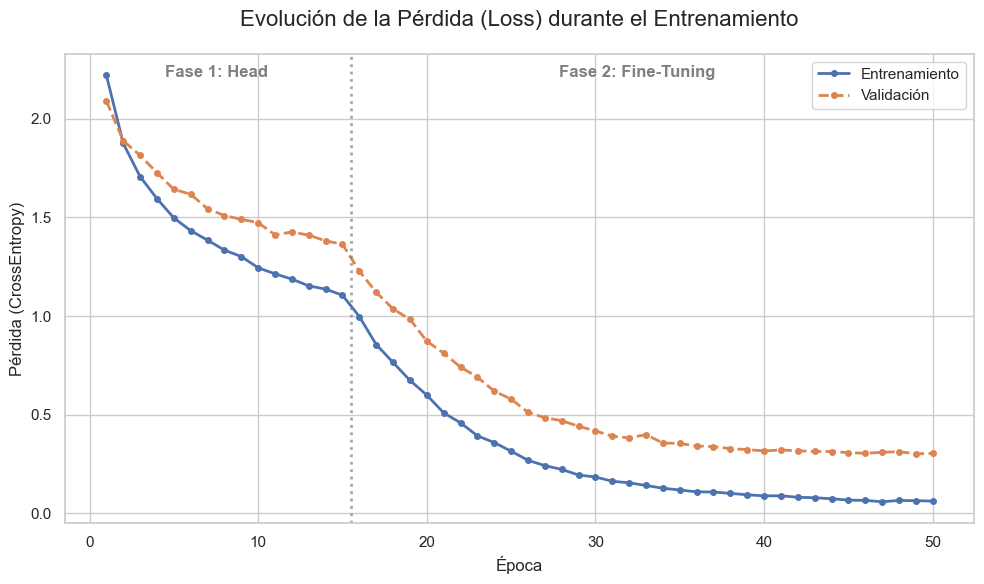

Gráfica guardada en: ./grafica_accuracy.png


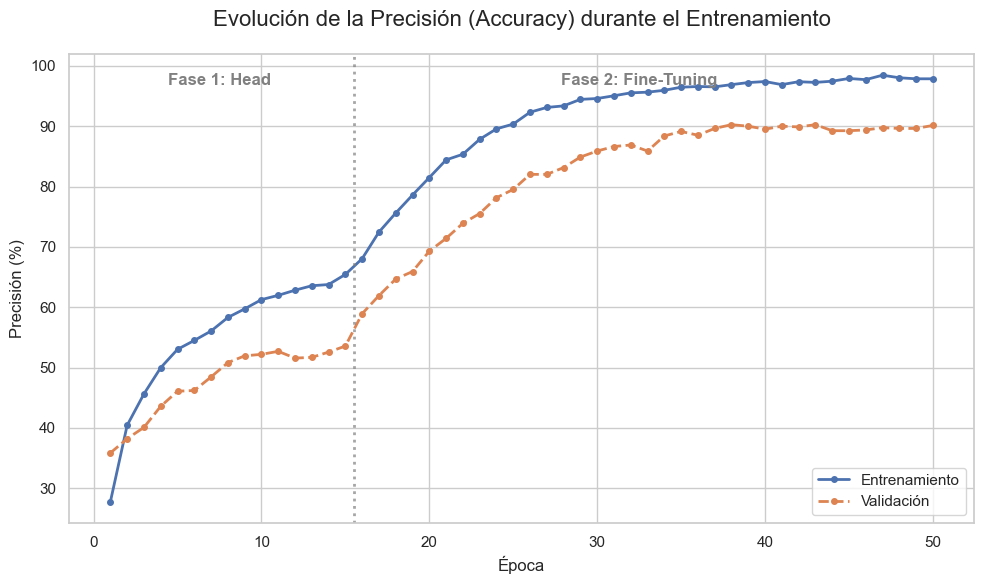

In [7]:
# Configuración
CSV_FILE = 'training_history.csv'
SAVE_DIR = '.' # Donde guardar las imágenes

# 1. Cargar datos
try:
    df = pd.read_csv(CSV_FILE)
    print(f"Datos cargados: {len(df)} épocas encontradas.")
except FileNotFoundError:
    print(f"Error: No se encuentra {CSV_FILE}")
    exit()

# 2. Configurar estilo de gráficas (Estilo Seaborn para que se vean profesionales)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# 3. Encontrar el punto de corte entre fases
# Buscamos la última época donde la fase es 'Head'
head_epochs = df[df['phase'] == 'Head']['epoch'].max()

# --- FUNCIÓN PARA DIBUJAR ---
def plot_metric(metric_name, train_col, val_col, title, ylabel, filename):
    plt.figure(figsize=(10, 6))
    
    # Dibujar líneas
    plt.plot(df['epoch'], df[train_col], label='Entrenamiento', linewidth=2, marker='o', markersize=4)
    plt.plot(df['epoch'], df[val_col], label='Validación', linewidth=2, marker='o', markersize=4, linestyle='--')
    
    # Dibujar línea vertical de separación de fases
    if head_epochs:
        plt.axvline(x=head_epochs + 0.5, color='gray', linestyle=':', linewidth=2, alpha=0.7)
        # Añadir texto para identificar las fases
        plt.text(head_epochs/2, plt.ylim()[1]*0.95, 'Fase 1: Head', ha='center', color='gray', fontweight='bold')
        plt.text(head_epochs + (df['epoch'].max() - head_epochs)/2, plt.ylim()[1]*0.95, 'Fase 2: Fine-Tuning', ha='center', color='gray', fontweight='bold')

    plt.title(title, fontsize=16, pad=20)
    plt.xlabel('Época', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    
    # Guardar
    save_path = f"{SAVE_DIR}/{filename}"
    plt.savefig(save_path, dpi=300)
    print(f"Gráfica guardada en: {save_path}")
    plt.show()

# --- GENERAR GRÁFICAS ---

# 1. Gráfica de PÉRDIDA (Loss)
plot_metric(
    metric_name='Loss',
    train_col='train_loss',
    val_col='val_loss',
    title='Evolución de la Pérdida (Loss) durante el Entrenamiento',
    ylabel='Pérdida (CrossEntropy)',
    filename='grafica_loss.png'
)

# 2. Gráfica de PRECISIÓN (Accuracy)
plot_metric(
    metric_name='Accuracy',
    train_col='train_acc',
    val_col='val_acc',
    title='Evolución de la Precisión (Accuracy) durante el Entrenamiento',
    ylabel='Precisión (%)',
    filename='grafica_accuracy.png'
)

# EVALUA EL MODELO

Modelo ResNet50 pre-entrenado cargado.
Todas las capas congeladas, excepto la capa final (model.fc).


C:\Users\ivanp\AppData\Local\Temp\ipykernel_23564\1718024634.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ruta_modelo, map_location=d

✅ Pesos de 'best_model.pth' cargados exitosamente.
Evaluando usando el conjunto de: test
Generando predicciones...

 RESULTADOS DE LA EVALUACIÓN
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        69
           1       0.90      0.95      0.92        56
           2       0.78      0.78      0.78        41
           3       0.92      0.60      0.73        20
           4       0.74      0.74      0.74        35
           5       0.96      0.96      0.96        45
           6       0.89      0.89      0.89        56
           7       0.83      0.94      0.88        47
           8       0.90      0.80      0.85        45
           9       0.73      0.74      0.74        43
          10       0.78      0.85      0.82        47
          11       0.85      0.95      0.90        55
          12       0.72      0.60      0.65        30
          13       0.96      0.96      0.96        47

    accuracy                           0.86

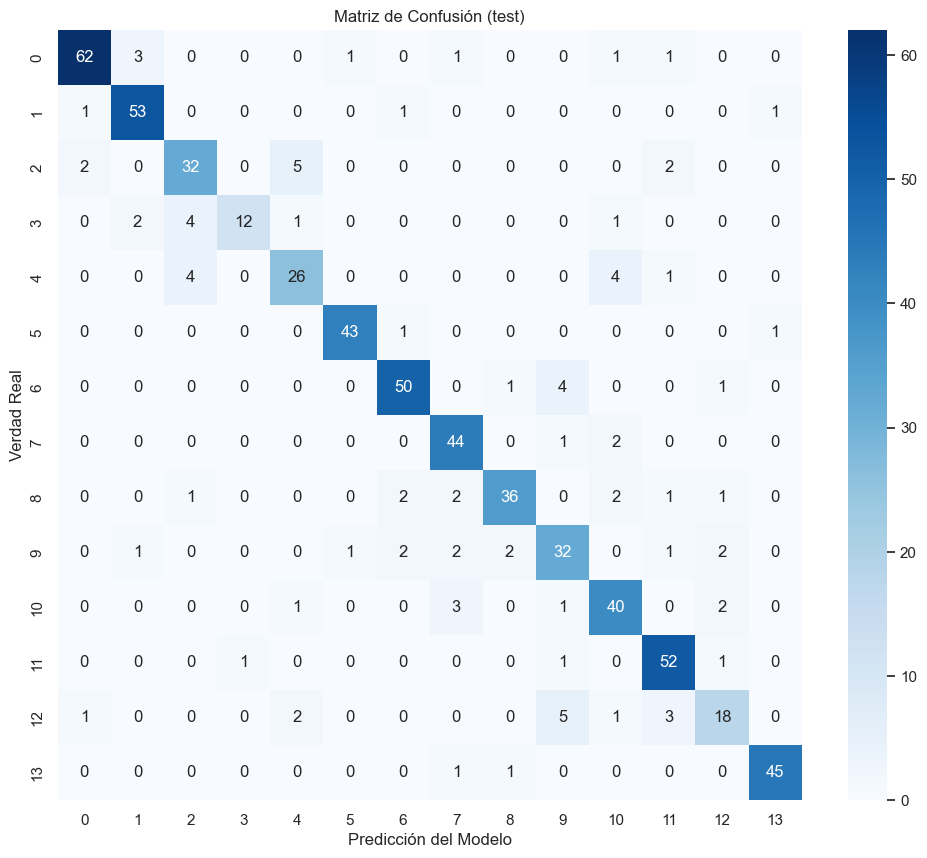

In [8]:
# 1. Configuración inicial (Usa la misma función que definiste antes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model(num_classes=14) 

# 2. Cargar los pesos aprendidos (best_model.pth)
ruta_modelo = 'best_model.pth'
if os.path.exists(ruta_modelo):
    model.load_state_dict(torch.load(ruta_modelo, map_location=device))
    print("✅ Pesos de 'best_model.pth' cargados exitosamente.")
else:
    print("❌ Error: No encuentro 'best_model.pth'. Asegúrate de que el archivo esté en la carpeta.")

model = model.to(device)
model.eval() # IMPORTANTE: Poner en modo evaluación

# 3. Elegir qué datos usar para la prueba
nombre_split = 'test' if 'test' in dataloaders else 'valid'
loader_prueba = dataloaders[nombre_split]
print(f"Evaluando usando el conjunto de: {nombre_split}")

# 4. Ejecutar predicciones
all_preds = []
all_labels = []

print("Generando predicciones...")
with torch.no_grad(): # Apagamos el cálculo de gradientes para ir rápido
    for images, labels in loader_prueba:
        if -1 in labels: continue # Ignorar etiquetas inválidas si las hay
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 5. Calcular métricas
print("\n" + "="*30)
print(" RESULTADOS DE LA EVALUACIÓN")
print("="*30)

# Reporte numérico detallado
nombres_clases = [str(i) for i in range(14)] # Por defecto 0 al 13

print(classification_report(all_labels, all_preds, target_names=nombres_clases))

# 6. Generar y GUARDAR Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10)) # Hacemos la figura un poco más grande

# Dibujar el mapa de calor
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.xlabel('Predicción del Modelo')
plt.ylabel('Verdad Real')
plt.title(f'Matriz de Confusión ({nombre_split})')

nombre_matriz = 'matriz_confusion.png'
plt.savefig(nombre_matriz, dpi=300, bbox_inches='tight') 
print(f"Matriz de confusión guardada como: {nombre_matriz}")

plt.show()